<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/Customer_Segmentation_Analysis_Using_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
data = {
    'CustomerID': range(1, 21),
    'Age': [22, 25, 28, 35, 40, 45, 50, 23, 30, 38,
            42, 27, 33, 48, 52, 29, 36, 44, 55, 31],

    'AnnualIncome': [25000, 30000, 35000, 60000, 75000,
                     80000, 90000, 28000, 45000, 65000,
                     70000, 32000, 55000, 85000, 95000,
                     40000, 62000, 78000, 100000, 50000],

    'SpendingScore': [20, 25, 30, 70, 80,
                      85, 90, 35, 50, 75,
                      65, 40, 60, 85, 95,
                      45, 72, 88, 92, 55],

    'PurchaseFrequency': [2, 3, 4, 8, 10,
                          12, 15, 4, 6, 9,
                          8, 5, 7, 13, 16,
                          5, 9, 12, 17, 7]
}

df = pd.DataFrame(data)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,1,22,25000,20,2
1,2,25,30000,25,3
2,3,28,35000,30,4
3,4,35,60000,70,8
4,5,40,75000,80,10


In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         20 non-null     int64
 1   Age                20 non-null     int64
 2   AnnualIncome       20 non-null     int64
 3   SpendingScore      20 non-null     int64
 4   PurchaseFrequency  20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes
None

Missing Values:
CustomerID           0
Age                  0
AnnualIncome         0
SpendingScore        0
PurchaseFrequency    0
dtype: int64


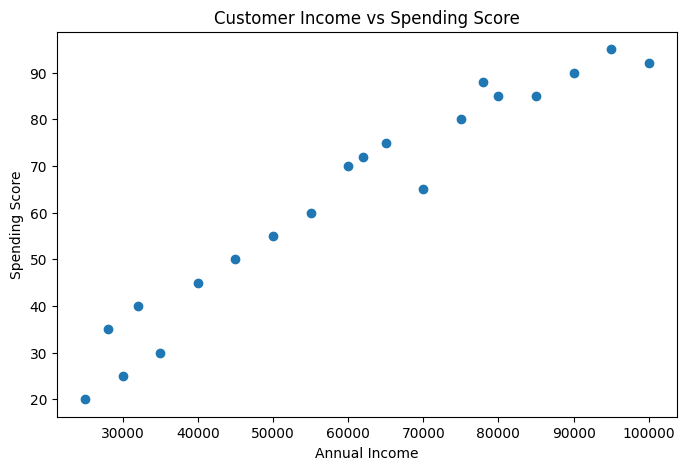

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore']
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Income vs Spending Score')

plt.show()

In [5]:
X = df[['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency']]

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.50284079, -1.51064282, -1.82592294, -1.54114773],
       [-1.19509182, -1.2948367 , -1.61286309, -1.30764049],
       [-0.88734285, -1.07903059, -1.39980323, -1.07413326],
       [-0.16926193,  0.        ,  0.30467559, -0.14010434],
       [ 0.34365301,  0.64741835,  0.7307953 ,  0.32691012]])

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster
0,1,22,25000,20,2,0
1,2,25,30000,25,3,0
2,3,28,35000,30,4,0
3,4,35,60000,70,8,3
4,5,40,75000,80,10,3


In [8]:
print(df['Cluster'].value_counts().sort_index())

Cluster
0    5
1    6
2    4
3    5
Name: count, dtype: int64


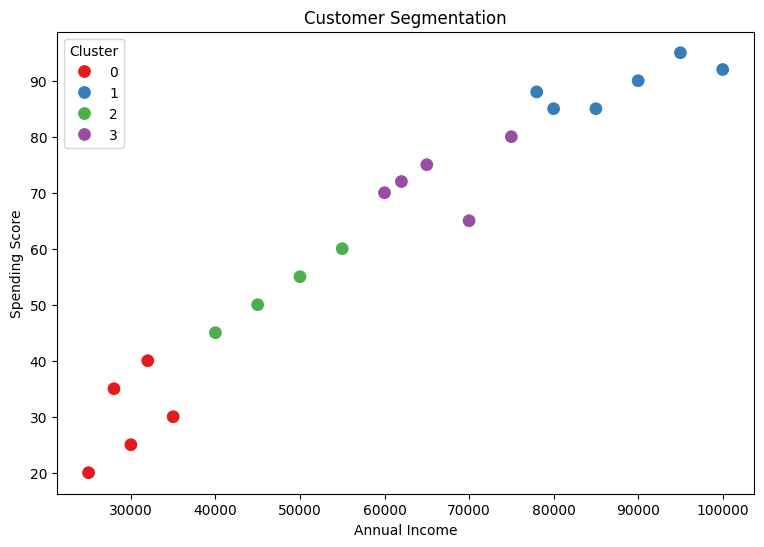

In [9]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='SpendingScore',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

In [10]:
cluster_analysis = df.groupby('Cluster')[
    ['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency']
].mean()

cluster_analysis

,Age,AnnualIncome,SpendingScore,PurchaseFrequency
Cluster,,,,
0,25.00,30000.0,30.000000,3.600000
1,49.00,88000.0,89.166667,14.166667
2,30.75,47500.0,52.500000,6.250000
3,38.20,66400.0,72.400000,8.800000


In [11]:
segment_names = {
    0: 'Low Value Customers',
    1: 'High Value Customers',
    2: 'Frequent Buyers',
    3: 'Medium Value Customers'
}

df['CustomerSegment'] = df['Cluster'].map(segment_names)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster,CustomerSegment
0,1,22,25000,20,2,0,Low Value Customers
1,2,25,30000,25,3,0,Low Value Customers
2,3,28,35000,30,4,0,Low Value Customers
3,4,35,60000,70,8,3,Medium Value Customers
4,5,40,75000,80,10,3,Medium Value Customers


In [12]:
final_data = df[
    [
        'CustomerID',
        'Age',
        'AnnualIncome',
        'SpendingScore',
        'PurchaseFrequency',
        'Cluster',
        'CustomerSegment'
    ]
]

final_data

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster,CustomerSegment
0,1,22,25000,20,2,0,Low Value Customers
1,2,25,30000,25,3,0,Low Value Customers
2,3,28,35000,30,4,0,Low Value Customers
3,4,35,60000,70,8,3,Medium Value Customers
4,5,40,75000,80,10,3,Medium Value Customers
5,6,45,80000,85,12,1,High Value Customers
6,7,50,90000,90,15,1,High Value Customers
7,8,23,28000,35,4,0,Low Value Customers
8,9,30,45000,50,6,2,Frequent Buyers
9,10,38,65000,75,9,3,Medium Value Customers


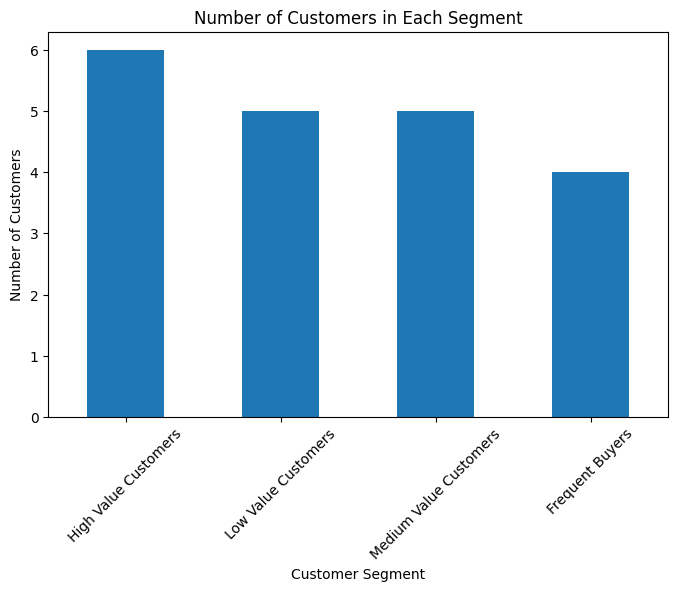

In [13]:
plt.figure(figsize=(8,5))

df['CustomerSegment'].value_counts().plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)
plt.show()